In [20]:
!pip install xgboost shap -q


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import shap
import matplotlib.pyplot as plt

In [22]:
df_train1 = pd.read_parquet("../data/feature_matrix_full_subset_train.parquet")

In [23]:
df_train1.head()

,upvotes,is_comment,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,sentence_length_std,paragraph_count,flesch_kincaid,...,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,label,source,split
0,742.0,0,3184,530,24,5.001887,22.083333,14.445059,4,12.447139,...,0.056788,-0.061332,0.051037,0.057017,-0.038635,-0.001076,-0.004114,1,human,train
1,1.0,1,230,44,4,4.250000,11.000000,6.519202,1,6.489091,...,0.104488,0.003214,-0.113515,0.083750,0.025363,0.082857,0.084013,1,human,train
2,188.0,0,174,31,2,4.612903,15.500000,8.500000,2,8.345323,...,-0.089276,-0.046865,0.014929,-0.026319,0.005514,-0.076127,0.002970,1,human,train
3,0.0,1,359,56,5,5.428571,11.200000,5.635601,1,8.725704,...,-0.040336,0.064563,0.003520,-0.022768,0.024074,0.067790,-0.009521,0,ai,train
4,0.0,1,336,55,2,5.127273,27.500000,14.500000,1,15.043704,...,-0.062633,-0.047471,0.050383,0.081916,0.021424,-0.043085,-0.033307,0,ai,train


In [ ]:
# Embedding columns – adjust if your columns have a different prefix
embed_cols = [f'emb_{i}' for i in range(384)]

# All other features (numerical, already preprocessed)
other_features = [  
]

target_col = 'upvotes'  



In [25]:
train_df = pd.read_parquet("../data/feature_matrix_full_subset_train.parquet")
val_df   = pd.read_parquet("../data/feature_matrix_full_subset_val.parquet")
test_df  = pd.read_parquet("../data/feature_matrix_full_subset_test.parquet")

In [26]:
X_train_embed = train_df[embed_cols].values
X_train_other = train_df[other_features].values
y_train = train_df[target_col].values

X_val_embed = val_df[embed_cols].values
X_val_other = val_df[other_features].values
y_val = val_df[target_col].values

X_test_embed = test_df[embed_cols].values
X_test_other = test_df[other_features].values
y_test = test_df[target_col].values

print(f"Train size: {len(X_train_embed)}")
print(f"Val size:   {len(X_val_embed)}")
print(f"Test size:  {len(X_test_embed)}")

Train size: 9541
Val size:   2045
Test size:  2045


In [27]:
scaler_embed = StandardScaler()
X_train_embed_scaled = scaler_embed.fit_transform(X_train_embed)
X_val_embed_scaled   = scaler_embed.transform(X_val_embed)
X_test_embed_scaled  = scaler_embed.transform(X_test_embed)

In [28]:
n_components = 30
pca = PCA(n_components=n_components, random_state=42)

X_train_embed_pca = pca.fit_transform(X_train_embed_scaled)
X_val_embed_pca   = pca.transform(X_val_embed_scaled)
X_test_embed_pca  = pca.transform(X_test_embed_scaled)

# Check how much variance is retained
explained_var = pca.explained_variance_ratio_.sum()
print(f"Explained variance with {n_components} components: {explained_var:.3f}")

Explained variance with 30 components: 0.400


In [29]:
X_train_final = np.hstack([X_train_embed_pca, X_train_other])
X_val_final   = np.hstack([X_val_embed_pca,   X_val_other])
X_test_final  = np.hstack([X_test_embed_pca,  X_test_other])

print("Final training shape:", X_train_final.shape)

Final training shape: (9541, 90)


In [34]:
model_xgb = xgb.XGBRegressor(
    n_estimators=500,            # maximum number of trees
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,    # stop if no improvement on val set
    eval_metric='mae'             # track mean absolute error
)

model_xgb.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
)

[0]	validation_0-mae:191.07304
[1]	validation_0-mae:190.72112
[2]	validation_0-mae:190.13145
[3]	validation_0-mae:189.80619
[4]	validation_0-mae:189.71253
[5]	validation_0-mae:189.83409
[6]	validation_0-mae:189.56590
[7]	validation_0-mae:189.38359
[8]	validation_0-mae:189.11564
[9]	validation_0-mae:189.21296
[10]	validation_0-mae:189.13685
[11]	validation_0-mae:189.23546
[12]	validation_0-mae:189.40393
[13]	validation_0-mae:189.67229
[14]	validation_0-mae:189.86606
[15]	validation_0-mae:190.06177
[16]	validation_0-mae:190.37652
[17]	validation_0-mae:191.16158
[18]	validation_0-mae:192.89118
[19]	validation_0-mae:194.18350
[20]	validation_0-mae:193.97116
[21]	validation_0-mae:194.09804
[22]	validation_0-mae:194.16822
[23]	validation_0-mae:194.09283
[24]	validation_0-mae:193.94846
[25]	validation_0-mae:194.04821
[26]	validation_0-mae:194.31751
[27]	validation_0-mae:194.59001
[28]	validation_0-mae:195.00581


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, early_stopping_rounds=20,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=500, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

In [31]:
y_pred = model_xgb.predict(X_test_final)
test_mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 284.7049


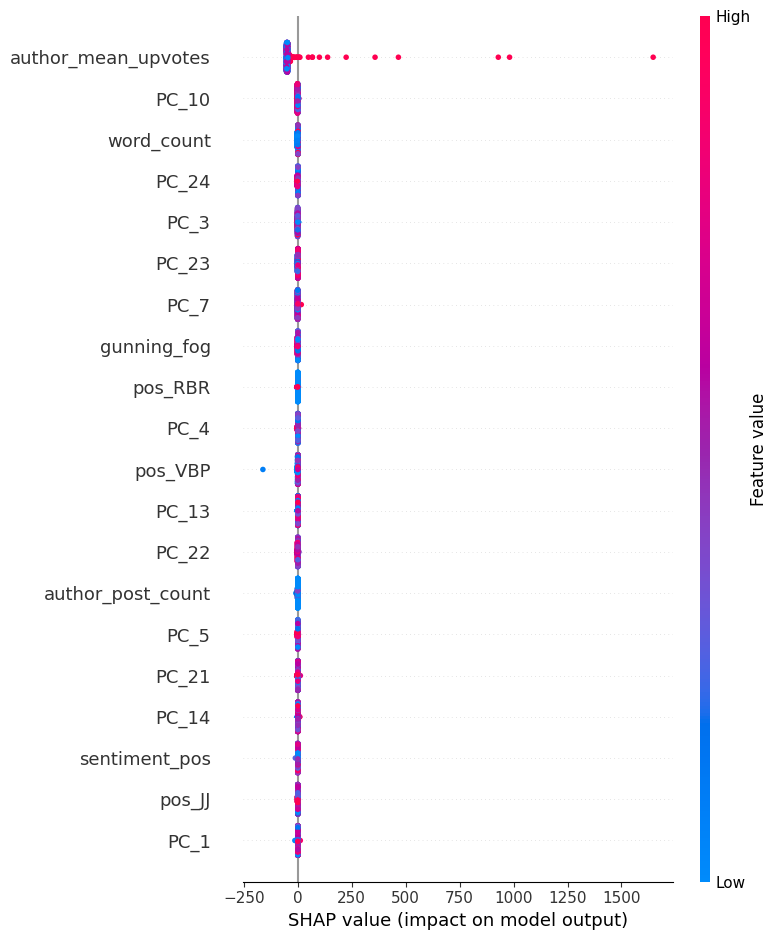

In [32]:
# Create a SHAP explainer (may take a minute if test set is large)
explainer = shap.TreeExplainer(model_xgb)

# Compute SHAP values on a sample of the test set (to speed up)
X_sample = X_test_final[:1000]   # adjust sample size as needed
shap_values = explainer.shap_values(X_sample)

# Feature names for plotting
feature_names = [f'PC_{i+1}' for i in range(n_components)] + other_features

# Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

In [35]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² = {r2:.3f} (i.e., {r2*100:.1f}% of variance explained)")

R² = 0.002 (i.e., 0.2% of variance explained)


In [36]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE = {mape:.1f}%")

MAPE = inf%


C:\Users\Rald999\AppData\Local\Temp\ipykernel_21192\1140654278.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


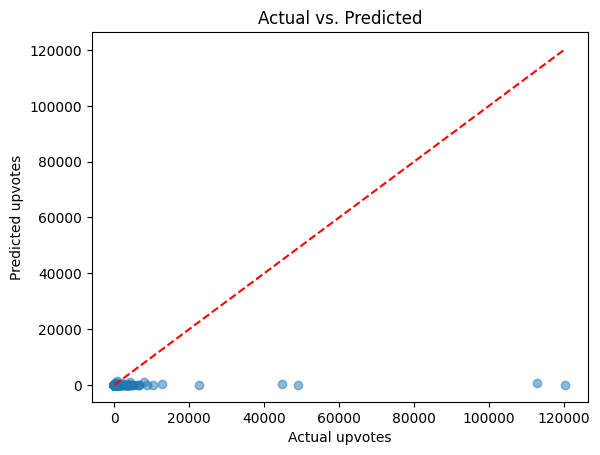

In [37]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual upvotes")
plt.ylabel("Predicted upvotes")
plt.title("Actual vs. Predicted")
plt.show()

In [ ]:
print(xxxxxxxxxxxxxxxxx5)

NameError: name 'xxxxxxxxxxxxxxxxx' is not defined

In [ ]:
df_train2 = pd.read_parquet("../data/feature_matrix_subset_train.parquet")
df_train2.head()

,upvotes,is_comment,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,sentence_length_std,paragraph_count,flesch_kincaid,...,burstiness,sentiment_compound,sentiment_pos,sentiment_neg,sentiment_neu,sentiment_variability,topic_id,label,source,split
0,742.0,0,3184,530,24,5.001887,22.083333,14.445059,4,12.447139,...,0.654116,0.9903,0.131,0.059,0.810,0.426107,0,1,human,train
1,1.0,1,230,44,4,4.250000,11.000000,6.519202,1,6.489091,...,0.592655,0.4939,0.152,0.070,0.778,0.182301,0,1,human,train
2,188.0,0,174,31,2,4.612903,15.500000,8.500000,2,8.345323,...,0.548387,0.5093,0.099,0.000,0.901,0.254650,0,1,human,train
3,0.0,1,359,56,5,5.428571,11.200000,5.635601,1,8.725704,...,0.503179,-0.8441,0.110,0.222,0.668,0.395493,0,0,ai,train
4,0.0,1,336,55,2,5.127273,27.500000,14.500000,1,15.043704,...,0.527273,0.7650,0.129,0.018,0.853,0.165200,0,0,ai,train


In [ ]:
df_train2.head(1).T.to_csv("../data/feature_matrix_subset_train.csv")

In [ ]:

df_train1.head(1).T.to_csv("../data/feature_matrix_subset_train_2.csv")

In [ ]:
df_train2.columns

Index(['upvotes', 'is_comment', 'char_count', 'word_count', 'sentence_count',
       'avg_word_length', 'avg_sentence_length', 'sentence_length_std',
       'paragraph_count', 'flesch_kincaid', 'gunning_fog', 'coleman_liau',
       'automated_readability', 'ttr', 'hapax_ratio', 'stopword_ratio',
       'punctuation_density', 'exclamation_count', 'question_count',
       'ellipsis_count', 'emoji_count', 'hour_of_day', 'day_of_week', 'pos_NN',
       'pos_NNS', 'pos_NNP', 'pos_VB', 'pos_VBD', 'pos_VBG', 'pos_VBN',
       'pos_VBP', 'pos_VBZ', 'pos_JJ', 'pos_JJR', 'pos_JJS', 'pos_RB',
       'pos_RBR', 'pos_RBS', 'pos_PRP', 'pos_DT', 'pos_IN', 'pos_CC',
       'trigram_repeat_rate', 'fourgram_repeat_rate', 'hedging_per_100w',
       'self_reference_rate', 'formality_score', 'author_post_count',
       'author_mean_word_count', 'author_std_word_count',
       'author_mean_upvotes', 'author_community_diversity',
       'author_mean_hedging', 'inter_post_median', 'inter_post_std',
       'pe

In [ ]:
df_train3 = pd.read_parquet("../data/features_subset_train.parquet")
df_train3.head()

,author,created_utc,id,upvotes,subreddit,label,interaction_type,text,post_id,source,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,topic_id
0,blueC11,2018-09-27 22:19:28,9jhblc,742.0,philosophy,1,post,My analysis on why nihilism might unhinge some...,9jhblc,human,...,0.018506,-0.009299,0.056788,-0.061332,0.051037,0.057017,-0.038635,-0.001076,-0.004114,0
1,matablue,2023-01-11 08:09:43,j3v9t6j,1.0,todayilearned,1,comment,ive seen all the LOTR movies and every Harry P...,d3u58,human,...,-0.046464,0.029447,0.104488,0.003214,-0.113515,0.083750,0.025363,0.082857,0.084013,0
2,jzzsxm,2011-03-28 19:57:55,gddgj,188.0,todayilearned,1,post,TIL that if you physically pick up a ringing A...,gddgj,human,...,0.014316,0.061264,-0.089276,-0.046865,0.014929,-0.026319,0.005514,-0.076127,0.002970,0
3,happy_milvus,2026-02-07T23:41:40.309506+00:00,379bb9c0-e49d-4bcd-83c6-c0a7ad075a7b,0.0,todayilearned,0,comment,Appreciate the deep dive. One thing we learned...,f0325501-7ab5-4f64-b4b2-10a57328de38,ai,...,-0.078806,0.018499,-0.040336,0.064563,0.003520,-0.022768,0.024074,0.067790,-0.009521,0
4,ClimateChampion,2026-02-05T09:03:16.153852+00:00,59d96d12-0db6-444f-917f-2a85e655f02a,0.0,technology,0,comment,One crucial human value that often gets overlo...,98255925-bcb2-478a-a84d-1c277b4fffe6,ai,...,-0.007849,-0.031760,-0.062633,-0.047471,0.050383,0.081916,0.021424,-0.043085,-0.033307,0
